# MCDI501 - Estadística Computacional para la Toma de Decisiones

## Fase 1 - Exploración del conjunto de datos

### Proyecto

**Predicción del riesgo de enfermedad cardiovascular utilizando el estudio Framingham**

**Dataset:** Framingham Heart Study

**Integrantes**
- Pablo Rodríguez
- Luiskar Espinoza

**Fecha:** (completar)

---

## Objetivo

Realizar una exploración inicial del conjunto de datos Framingham Heart Study, identificando sus variables, tipos de datos y posibles relaciones, como base para posteriores análisis estadísticos e inferenciales.

In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Ruta raíz del proyecto
PROJECT_ROOT = Path.cwd().parents[1]

# Ruta del dataset
DATASET = PROJECT_ROOT /"mcdi501_grupo6" / "datos" / "original" / "framingham.csv"

print("Proyecto:", PROJECT_ROOT)
print("Dataset:", DATASET)

Proyecto: C:\users\pablo\documents
Dataset: C:\users\pablo\documents\mcdi501_grupo6\datos\original\framingham.csv


In [6]:
df = pd.read_csv(DATASET)

print("Dataset cargado correctamente.")

Dataset cargado correctamente.


In [7]:
print("Filas :", df.shape[0])
print("Columnas :", df.shape[1])

Filas : 4238
Columnas : 16


In [8]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [9]:
list(df.columns)

['male',
 'age',
 'education',
 'currentSmoker',
 'cigsPerDay',
 'BPMeds',
 'prevalentStroke',
 'prevalentHyp',
 'diabetes',
 'totChol',
 'sysBP',
 'diaBP',
 'BMI',
 'heartRate',
 'glucose',
 'TenYearCHD']

In [10]:
# Información general del dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [11]:
# Estadísticas descriptivas

df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [12]:
# Valores faltantes por variable

df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [13]:
print(f"Número de registros : {df.shape[0]}")
print(f"Número de variables : {df.shape[1]}")

Número de registros : 4238
Número de variables : 16


In [14]:
tipos = pd.DataFrame({
    "Variable": df.columns,
    "Tipo": df.dtypes.values
})

tipos

,Variable,Tipo
0,male,int64
1,age,int64
2,education,float64
3,currentSmoker,int64
4,cigsPerDay,float64
5,BPMeds,float64
6,prevalentStroke,int64
7,prevalentHyp,int64
8,diabetes,int64
9,totChol,float64


In [15]:
df["TenYearCHD"].value_counts()

TenYearCHD
0    3594
1     644
Name: count, dtype: int64

In [16]:
df["TenYearCHD"].value_counts(normalize=True) * 100

TenYearCHD
0    84.804153
1    15.195847
Name: proportion, dtype: float64

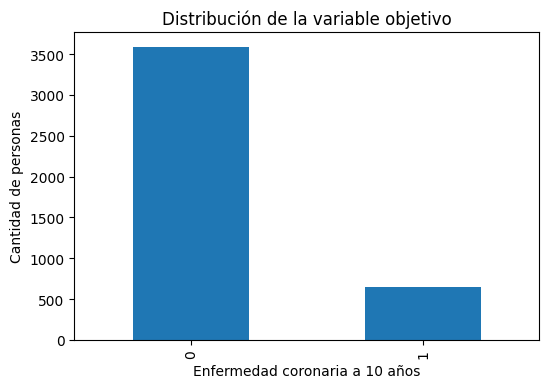

In [17]:
plt.figure(figsize=(6,4))

df["TenYearCHD"].value_counts().plot(kind="bar")

plt.title("Distribución de la variable objetivo")
plt.xlabel("Enfermedad coronaria a 10 años")
plt.ylabel("Cantidad de personas")

plt.show()